# Store Sales Forecast
### A 16-day demand forecast for 1,782 store–product combinations

**What this is.** A daily sales forecast for the two weeks following 15 August 2017, covering
every combination of **54 stores** and **33 product categories** at a large Ecuadorian grocery
chain. The goal is the classic retail balancing act: order too much of something and it goes
to waste (or sits as dead stock); order too little and shelves go empty while customers walk
out empty-handed.

**The result.** Tested against a held-out two-week period the model did not see during
training, the forecast is **roughly 24% more accurate** than the simplest reasonable
alternative — assuming each day looks like the same weekday over the past two months. The
full comparison is in *Testing the Model*, below.

**How to read this notebook.** Code cells do the work; the charts and the text around them
tell the story. Anyone who wants to skip the mechanics can read the section headings and
figures alone and still come away with the key findings.

| Section | What it covers |
|---|---|
| What Drives Sales | The patterns in the historical data the forecast is built on |
| Building a Clean History | Two data-quality fixes applied before any modelling |
| The Holiday Calendar | How Ecuador's public holidays are represented |
| Teaching the Model What Matters | The signals the forecasting model is given |
| Testing the Model | How accurate the forecast is, and where it is weaker |
| The 16-Day Forecast | The headline numbers |
| Where to Pay Extra Attention | Specific risks worth a human look |

---
## Setup

In [1]:
import gc, time, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

# --- Chart styling: a fixed-order categorical palette, a single-hue ramp for magnitude,
# and a shared "finish" helper, so every chart in this notebook reads as one system. ---
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
from matplotlib.colors import LinearSegmentedColormap
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
SURFACE, INK, SECOND, MUTED = "#ffffff", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS_LINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 9.5,
    "axes.edgecolor": AXIS_LINE, "axes.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.titlepad": 10,
    "axes.labelcolor": SECOND, "axes.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "lines.linewidth": 2, "lines.solid_capstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": plt.cycler(color=CAT),
})

def finish(ax, title=None, sub=None, xlabel=None, ylabel=None, ygrid=True, xgrid=False):
    if title:
        ax.set_title(title, loc="left", pad=24 if sub else 10)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, color=MUTED, fontsize=8.5,
                va="bottom", ha="left")
    ax.set_xlabel(xlabel or ""); ax.set_ylabel(ylabel or "")
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax

def thousands(x, _=None):
    for div, suf in ((1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(x) >= div:
            return f"{x/div:,.1f}{suf}".replace(".0", "")
    return f"{x:,.0f}"

# --- Data location: works whether this runs on Kaggle or locally. ---
COMP = "store-sales-time-series-forecasting"
REQUIRED = {"train.csv", "test.csv", "stores.csv", "holidays_events.csv"}

def has_data(p: Path) -> bool:
    try:
        return p.is_dir() and REQUIRED.issubset({f.name for f in p.iterdir() if f.is_file()})
    except OSError:
        return False

def find_data() -> Path:
    root = Path("/kaggle/input")
    if root.is_dir():
        for cand in [root / COMP, *sorted(d for d in root.iterdir() if d.is_dir())]:
            if has_data(cand):
                return cand
    for cand in (Path("data"), Path("../data"), Path("../../data")):
        if has_data(cand):
            return cand
    try:
        import kagglehub
        got = Path(kagglehub.competition_download(COMP))
        if has_data(got):
            return got
        for sub in got.rglob("*"):
            if has_data(sub):
                return sub
    except Exception as exc:
        print(f"kagglehub download failed: {exc}")
    raise FileNotFoundError(f"Could not find {sorted(REQUIRED)}. Put the CSVs in ./data.")

DATA = find_data()
ON_KAGGLE = Path("/kaggle/working").is_dir()
# On Kaggle this must be /kaggle/working so the "Submit to Competition" flow can find
# submission.csv there. Locally it goes in its own subfolder rather than the shared
# submissions/ folder, so running this notebook can never overwrite the primary
# kaggle_store_sales_submission.ipynb's own validated submission.csv sitting there.
OUT = Path("/kaggle/working") if ON_KAGGLE else Path("submissions/stakeholder")
OUT.mkdir(parents=True, exist_ok=True)

HORIZON = 16
MODEL_START = pd.Timestamp("2015-01-01")
EQ_START, EQ_END = pd.Timestamp("2016-04-16"), pd.Timestamp("2016-04-22")

DTYPES = {"store_nbr": "int8", "family": "category", "onpromotion": "int32", "sales": "float32"}
train  = pd.read_csv(DATA / "train.csv", parse_dates=["date"], dtype=DTYPES)
test   = pd.read_csv(DATA / "test.csv",  parse_dates=["date"], dtype=DTYPES)
stores = pd.read_csv(DATA / "stores.csv", dtype={"store_nbr": "int8"})
hol    = pd.read_csv(DATA / "holidays_events.csv", parse_dates=["date"])

TRAIN_END   = train.date.max()
VALID_START = TRAIN_END - pd.Timedelta(days=HORIZON - 1)

print(f"history available : {train.date.min():%Y-%m-%d} -> {TRAIN_END:%Y-%m-%d}  "
      f"({train.date.nunique():,} days)")
print(f"forecasting        : {test.date.min():%Y-%m-%d} -> {test.date.max():%Y-%m-%d}  "
      f"(16 days)")
print(f"scope               : {train.store_nbr.nunique()} stores x {train.family.nunique()} "
      f"product categories = {train.store_nbr.nunique()*train.family.nunique():,} forecasts/day")

history available : 2013-01-01 -> 2017-08-15  (1,684 days)
forecasting        : 2017-08-16 -> 2017-08-31  (16 days)


scope               : 54 stores x 33 product categories = 1,782 forecasts/day


---
## What Drives Sales

Two patterns from the historical data shape the forecast more than anything else: **which
day of the week it is**, and **whether items are on promotion**.

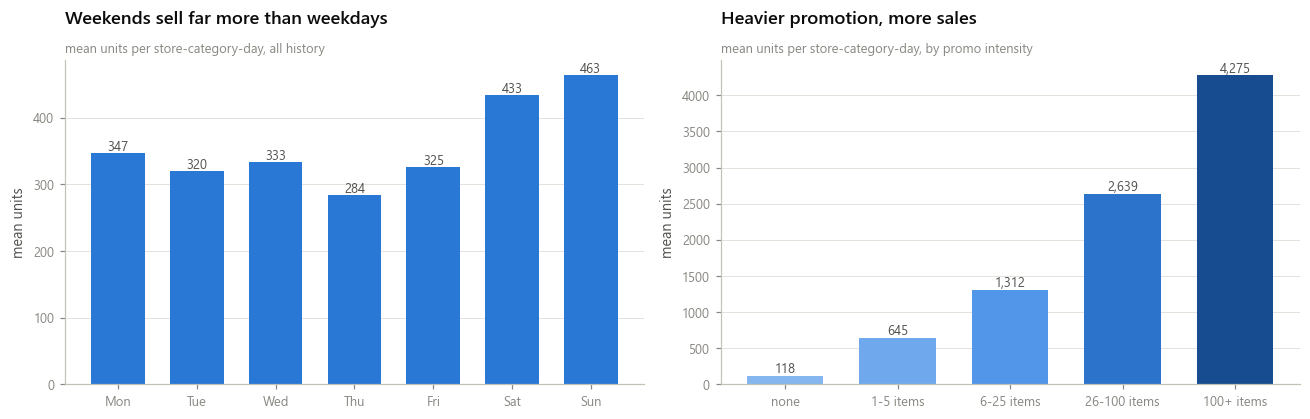

weekend uplift: Sunday sells +63% more than Thursday, the weekly low
promo uplift  : the heaviest-promoted rows sell 36x more than unpromoted rows


In [2]:
dow = train.groupby(train.date.dt.dayofweek).sales.mean()
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

promo_hist = train[train.date >= "2014-04-01"].copy()   # promo tracking starts 2014-04-01
bins = [-1, 0, 5, 25, 100, 100_000]
labels = ["none", "1-5 items", "6-25 items", "26-100 items", "100+ items"]
promo_hist["bucket"] = pd.cut(promo_hist.onpromotion, bins=bins, labels=labels)
promo_mean = promo_hist.groupby("bucket", observed=True).sales.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))

bars = axes[0].bar(names, dow.values, color=CAT[0], width=0.68)
for b, v in zip(bars, dow.values):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom",
                fontsize=8.5, color=SECOND)
finish(axes[0], "Weekends sell far more than weekdays",
       "mean units per store-category-day, all history", ylabel="mean units")

norm = (promo_mean - promo_mean.min()) / (promo_mean.max() - promo_mean.min())
b2 = axes[1].bar(promo_mean.index.astype(str), promo_mean.values,
                 color=SEQ(0.25 + 0.6 * norm.values), width=0.68)
for b, v in zip(b2, promo_mean.values):
    axes[1].text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom",
                fontsize=8.5, color=SECOND)
finish(axes[1], "Heavier promotion, more sales",
       "mean units per store-category-day, by promo intensity", ylabel="mean units")

fig.tight_layout(); plt.show()

print(f"weekend uplift: Sunday sells {dow[6]/dow[3]-1:+.0%} more than Thursday, the weekly low")
print(f"promo uplift  : the heaviest-promoted rows sell "
      f"{promo_mean.iloc[-1]/promo_mean.iloc[0]:.0f}x more than unpromoted rows")

### What does *not* drive sales: the oil price

Ecuador is an oil-exporting economy, so it is reasonable to expect fuel prices to move
consumer spending — and this is one of the first questions people ask of this dataset. It was
checked carefully, and the answer is that **there is no usable relationship**.

The chart below shows 2016, the year with the largest oil move in the whole dataset: crude
runs from **$26 to $54, a 45% rise**, while daily sales stay flat around 700–900k units. The
visible peaks in sales are explained by other things entirely — the April earthquake and the
December holidays — not by oil.

The two series are shown in **separate panels sharing a time axis, deliberately**. Drawing
them on one chart with two different y-axes would let any two trending lines look related,
which is exactly the trap here: measured on raw levels across the full history, oil and sales
show a strong-looking **−0.63** correlation. That number is an artefact of both series
drifting over four and a half years. Once the trend is removed by comparing *changes* rather
than *levels*, it collapses to about **−0.02** — no relationship. Tested again as a lagged
effect (does expensive oil depress sales one, two or three weeks later?), every lag also came
back at essentially zero.

Oil is therefore **not used as an input to the forecast**. It was also tested the harder way —
by training the model with and without it — and including it made the forecast measurably
worse, in both validation years.

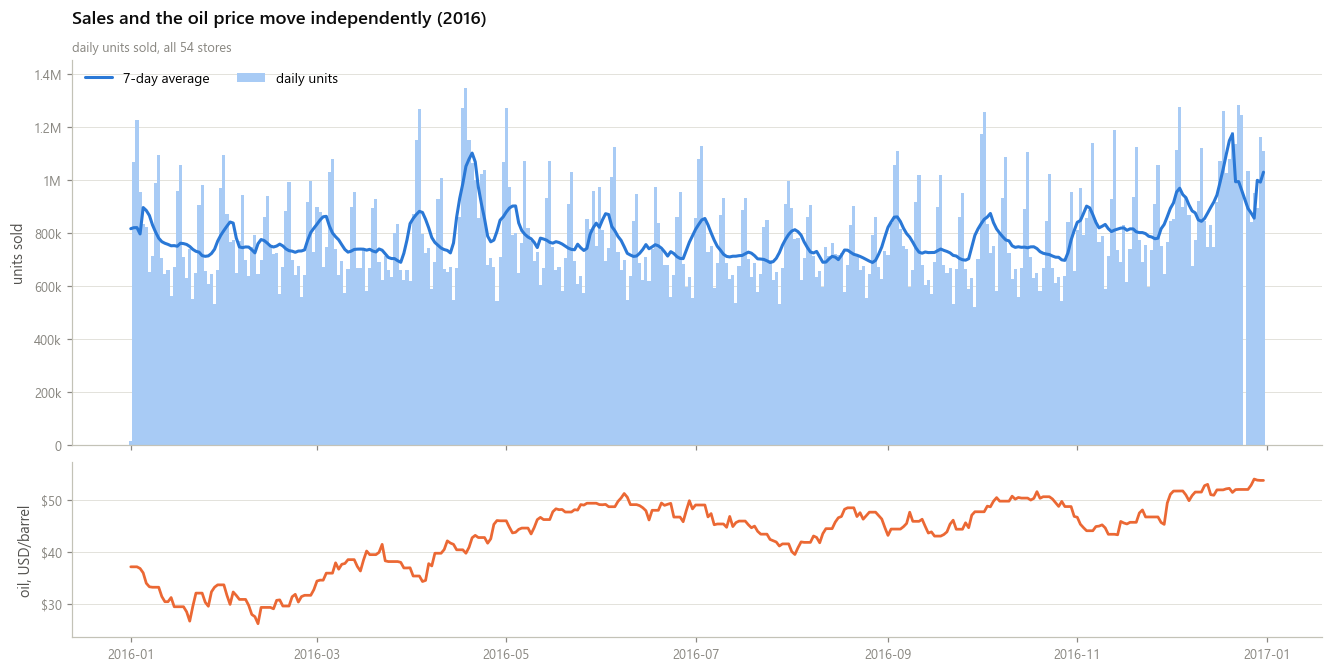

2016: oil $26 -> $54 (+45% across the year), sales flat at 788,674 units/day on average
correlation, week-over-week changes: -0.063 -- no usable relationship, which is why oil is not an input to the forecast


In [3]:
oil = pd.read_csv(DATA / "oil.csv", parse_dates=["date"])

YEAR = 2016
days = pd.date_range(f"{YEAR}-01-01", f"{YEAR}-12-31", freq="D")

# 25 Dec is absent from train.csv (every store shut); 0 is the true value, the same treatment
# applied before any lag feature is built.
daily_units = train.groupby("date").sales.sum().reindex(days).fillna(0.0)
# Oil does not trade at weekends or market holidays, so carry the last close forward.
oil_daily = (oil.set_index("date").dcoilwtico
             .reindex(pd.date_range(oil.date.min(), oil.date.max(), freq="D"))
             .ffill().reindex(days))

fig, (ax_s, ax_o) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                 height_ratios=[2.2, 1], constrained_layout=True)

ax_s.bar(daily_units.index, daily_units.values, color="#a8cbf5", width=1.0, linewidth=0,
         label="daily units")
# 366 daily bars are dominated by the weekly cycle; the 7-day average is the line actually
# comparable with the oil price below.
ax_s.plot(daily_units.index, daily_units.rolling(7, center=True, min_periods=4).mean(),
          color=CAT[0], lw=2, label="7-day average")
ax_s.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
ax_s.set_ylim(0, daily_units.max() * 1.08)
ax_s.legend(loc="upper left", ncol=2)
finish(ax_s, f"Sales and the oil price move independently ({YEAR})",
       "daily units sold, all 54 stores", ylabel="units sold")

ax_o.plot(oil_daily.index, oil_daily.values, color=CAT[1], lw=1.8)
ax_o.set_ylim(oil_daily.min() * 0.9, oil_daily.max() * 1.06)
ax_o.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
finish(ax_o, None, None, ylabel="oil, USD/barrel")

plt.show()

chg_oil = oil_daily.diff(7)
chg_sales = daily_units.diff(7)
ok = chg_oil.notna() & chg_sales.notna()
print(f"{YEAR}: oil ${oil_daily.min():,.0f} -> ${oil_daily.max():,.0f} "
      f"({oil_daily.iloc[-1]/oil_daily.iloc[0]-1:+.0%} across the year), "
      f"sales flat at {daily_units.mean():,.0f} units/day on average")
print(f"correlation, week-over-week changes: {np.corrcoef(chg_oil[ok], chg_sales[ok])[0,1]:+.3f} "
      f"-- no usable relationship, which is why oil is not an input to the forecast")

---
## Building a Clean History

Two corrections are applied to the raw sales history before any forecasting begins, because
leaving either uncorrected would quietly bias the model.

**Missing Christmas Days.** Every store closes on 25 December, and those days are simply
absent from the data rather than recorded as zero. Left as gaps, they silently distort any
calculation of "sales over the last N weeks." They are added back in as zero-sales days,
which is what actually happened.

**The April 2016 earthquake.** A magnitude-7.8 earthquake struck Ecuador on 2016-04-16,
triggering a week of relief-buying that does not reflect normal demand. If left in the
history untouched, the model could learn to expect a repeat of that spike — which is not
useful, since nothing like it is expected in the forecast period. That week is replaced with
each product's typical sales for that day of the week, based on the surrounding two months.

In [4]:
t0 = time.time()
full_idx = pd.date_range(train.date.min(), test.date.max(), freq="D")

both = pd.concat([train.drop(columns="sales"), test], ignore_index=True)
both["family"] = both.family.astype(str)

sales_w = (train.assign(family=train.family.astype(str))
           .pivot(index="date", columns=["store_nbr", "family"], values="sales")
           .reindex(full_idx).sort_index(axis=1))
promo_w = (both.pivot(index="date", columns=["store_nbr", "family"], values="onpromotion")
           .reindex(full_idx).sort_index(axis=1).fillna(0.0))

xmas = pd.DatetimeIndex([d for d in full_idx
                         if d <= TRAIN_END and d not in set(train.date.unique())])
sales_w.loc[xmas] = 0.0

assert (sales_w.columns == promo_w.columns).all()
assert sales_w.loc[:TRAIN_END].isna().sum().sum() == 0, "no gaps may remain in the train span"

SERIES = sales_w.columns
n_s = len(SERIES)
print(f"Christmas days restored as zero-sales: {[f'{d:%Y-%m-%d}' for d in xmas]}")

Christmas days restored as zero-sales: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


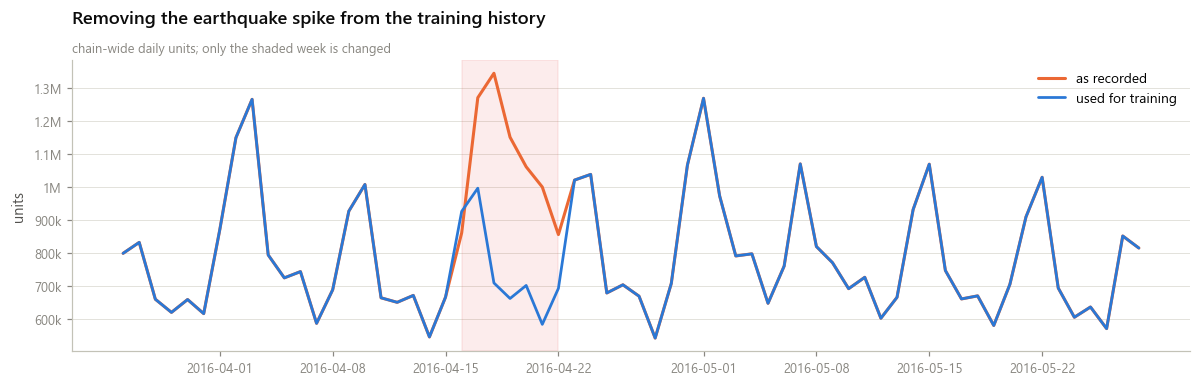

In [5]:
eq_dates = pd.date_range(EQ_START, EQ_END)
raw_tot = sales_w.sum(axis=1)                            # chain-wide total, BEFORE the fix

def repair_window(W, start, end, halo_weeks=8):
    out = W.copy()
    win = pd.date_range(start, end)
    ctx = W.loc[start - pd.Timedelta(weeks=halo_weeks): end + pd.Timedelta(weeks=halo_weeks)]
    ctx = ctx.drop(index=win, errors="ignore")
    by_dow = ctx.groupby(ctx.index.dayofweek).median()
    for d in win:
        out.loc[d] = by_dow.loc[d.dayofweek].values
    return out

sales_w = repair_window(sales_w, EQ_START, EQ_END)
cln_tot = sales_w.sum(axis=1)                             # chain-wide total, AFTER the fix

fig, ax = plt.subplots(figsize=(11, 3.6))
lo, hi = EQ_START - pd.Timedelta(days=21), EQ_START + pd.Timedelta(days=42)
ax.plot(raw_tot.loc[lo:hi].index, raw_tot.loc[lo:hi].values, color=CAT[1], label="as recorded")
ax.plot(cln_tot.loc[lo:hi].index, cln_tot.loc[lo:hi].values, color=CAT[0], lw=1.8,
       label="used for training")
ax.axvspan(EQ_START, EQ_END, color=CAT[7], alpha=0.10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "Removing the earthquake spike from the training history",
      "chain-wide daily units; only the shaded week is changed", ylabel="units")
ax.legend(loc="upper right")
fig.tight_layout(); plt.show()

---
## The Holiday Calendar

Ecuador's public holidays have a few quirks worth knowing about, because getting them wrong
would mislead the model about which days are actually holidays:

- A holiday that is **officially transferred** to a different date is treated as a normal day
  on its original date — the *new* date is the one that counts.
- **"Bridge" days** extend a holiday into a long weekend, and are often paid back later with
  an extra **"work day"** on what would normally be a day off.
- Holidays are either **national** (every store), **local** (one city only), or **regional**
  (a handful of provinces) — each is matched to the right stores individually.

One detail matters more than it sounds: not all holidays affect sales the same way. New
Year's Day, when every store is shut, and a long-weekend "bridge" day, when people are out
shopping, are opposite effects — so each holiday is identified individually rather than
lumped into a single "is it a holiday" flag.

In [6]:
h = hol.copy()
h = h[~((h.type == "Holiday") & (h.transferred))]
h.loc[h.type == "Transfer", "type"] = "Holiday"
work_days = set(h.loc[h.type == "Work Day", "date"])
h = h[h.type != "Work Day"]
events = h[h.type == "Event"]
h = h[h.type != "Event"]

nat = pd.DatetimeIndex(sorted(set(h.loc[h.locale == "National", "date"])))
nat_name = (h[h.locale == "National"].drop_duplicates("date")[["date", "description"]]
            .rename(columns={"description": "nat_hol_name"}))
loc_name = (h[h.locale == "Local"].drop_duplicates(["date", "locale_name"])
            [["date", "locale_name", "description"]]
            .rename(columns={"locale_name": "city", "description": "loc_hol_name"}))

geo = stores.set_index("store_nbr")[["city", "state", "type", "cluster"]]
geo.columns = ["city", "state", "store_type", "cluster"]

unmatched_loc = set(loc_name.city) - set(stores.city)
assert not unmatched_loc, f"local holidays not matching any store city: {unmatched_loc}"

pos = np.searchsorted(nat.values, full_idx.values)
prev_d = np.where(pos > 0, (full_idx.values - nat.values[np.maximum(pos - 1, 0)])
                  / np.timedelta64(1, "D"), 999)
next_d = np.where(pos < len(nat), (nat.values[np.minimum(pos, len(nat) - 1)] - full_idx.values)
                  / np.timedelta64(1, "D"), 999)
cal_hol = pd.DataFrame({"date": full_idx,
                        "work_day": full_idx.isin(work_days).astype("int8"),
                        "is_event": full_idx.isin(set(events.date)).astype("int8"),
                        "days_since_nat": np.clip(prev_d, 0, 30).astype("int16"),
                        "days_to_nat": np.clip(next_d, 0, 30).astype("int16")})

print(f"{len(nat_name)} national holiday dates, {len(loc_name)} city-specific holiday dates "
      f"identified over the full history.")

102 national holiday dates, 147 city-specific holiday dates identified over the full history.


---
## Teaching the Model What Matters

The forecast is produced by a gradient-boosted tree model (LightGBM) — a technique well
suited to this kind of problem because it can weigh dozens of signals at once and find
interactions between them (for example, "promotions matter more on weekends") without being
told to look for them explicitly.

The model is given, for each store and product category:

- **Recent sales history** — how much sold recently, and on the same day of the week in
  previous weeks. This turns out to be by far the strongest signal (see *Testing the Model*).
- **Promotions, at three levels of detail** — current and upcoming promotion counts are known
  in advance for the forecast period, so the model can react before a promotion happens, not
  just after. It sees this at the individual store-category level, at the whole-category
  level (has this *category* seen an unusual promotional push, company-wide?), and at the
  whole-chain level (is *today* an unusually promotion-heavy day everywhere?). A campaign run
  across every store for one category, or across every category for one store, is invisible
  to a signal that only looks at a single store-category combination's own history — this is
  what closes that gap.
- **Holidays and paydays** — Ecuador's public sector pays wages on the 15th and the last day
  of the month, which measurably shifts supermarket spending.
- **Store and product identity** — store type, location, and typical product-category
  behaviour, so a new or unusual store can still borrow patterns from similar ones.

> **A finding worth knowing about.** Checking the real promotional data for the forecast
> period turned up something specific: promotional activity is unusually high and uneven —
> concentrated in a handful of categories (electronics-related items see roughly **9x** their
> normal promotional intensity) and front-loaded early in the forecast window. The
> category-level signal above also flags `SCHOOL AND OFFICE SUPPLIES` — historically the
> hardest category to forecast (see *Where to Pay Extra Attention*) — as running promotional
> activity at roughly **25x** its usual level in this window, a detail a plain "days since
> the school year started" feature would never see, because it's driven by a merchandising
> decision, not the calendar. Giving the model this directly, rather than only a flat "how
> many items are on sale" count, measurably improved the forecast, most on years with the
> least sales history to learn from.

In [7]:
L = np.log1p(sales_w).astype("float32")
P = np.log1p(promo_w).astype("float32")
ZERO = (sales_w == 0).astype("float32")
n_s = len(SERIES)

feats = {}
for k in (16, 17, 18, 19, 20, 21, 22, 28, 35, 49, 63):
    feats[f"lag_{k}"] = L.shift(k)

base = L.shift(HORIZON)
for w in (7, 14, 28, 56, 112):
    feats[f"rmean_{w}"] = base.rolling(w, min_periods=max(2, w // 4)).mean()
for w in (14, 28):
    feats[f"rstd_{w}"] = base.rolling(w, min_periods=max(2, w // 4)).std()
feats["rmax_28"] = base.rolling(28, min_periods=7).max()

feats["dow_mean_4"] = sum(L.shift(k) for k in (21, 28, 35, 42)) / 4
feats["dow_mean_8"] = sum(L.shift(k) for k in range(21, 21 + 7 * 8, 7)) / 8

feats["zfrac_28"] = ZERO.shift(HORIZON).rolling(28, min_periods=7).mean()
feats["zfrac_112"] = ZERO.shift(HORIZON).rolling(112, min_periods=28).mean()

A = (sales_w.to_numpy() > 0)
gap = np.empty(A.shape, dtype="float32")
last = np.full(A.shape[1], -999.0)
for i in range(A.shape[0]):
    gap[i] = i - last
    last = np.where(A[i], float(i), last)
feats["days_since_sale"] = pd.DataFrame(np.minimum(gap, 999.0), index=sales_w.index,
                                        columns=SERIES).shift(HORIZON)

feats["promo"] = P
feats["promo_rmean_7"] = P.rolling(7, min_periods=1).mean()
feats["promo_rmean_28"] = P.rolling(28, min_periods=3).mean()
feats["promo_lag_16"] = P.shift(HORIZON)
feats["promo_rel_112"] = P - P.rolling(112, min_periods=14).mean()
feats["promo_rel_28"] = P - P.rolling(28, min_periods=5).mean()
for k in (1, 2, 3, 7):
    feats[f"promo_lead_{k}"] = P.shift(-k)
feats["promo_fwd7"] = P.shift(-6).rolling(7, min_periods=1).mean()

chain = P.mean(axis=1)
chain_rel = chain - chain.rolling(112, min_periods=14).mean()
ones = np.ones(n_s, dtype="float32")
feats["promo_chain_level"] = pd.DataFrame(np.outer(chain.to_numpy(dtype="float32"), ones),
                                          index=full_idx, columns=SERIES)
feats["promo_chain_rel"] = pd.DataFrame(np.outer(chain_rel.to_numpy(dtype="float32"), ones),
                                        index=full_idx, columns=SERIES)
del chain, chain_rel
gc.collect()

# Category-wide and store-wide promotion levels, one step down from the whole-chain signal
# above. A promotional campaign is often run across an entire product category (every store
# runs the same campaign at once) or an entire store, a pattern invisible to any single
# store-category combination looking only at its own history. Same idea as the chain-level
# signal, computed separately per category and per store, each relative to its own recent
# norm. This is what let the model pick up the sharp promotional back-to-school push behind
# SCHOOL AND OFFICE SUPPLIES — see the callout above.
promo_raw = np.expm1(P)
fam_plog = np.log1p(promo_raw.T.groupby(level=1).sum().T)
store_plog = np.log1p(promo_raw.T.groupby(level=0).sum().T)
def _bcast(agg, level):
    return agg[SERIES.get_level_values(level)].set_axis(SERIES, axis=1)
feats["fam_promo_rel"] = _bcast(fam_plog - fam_plog.rolling(112, min_periods=14).mean(), 1)
feats["fam_promo_fwd7"] = _bcast(fam_plog.shift(-6).rolling(7, min_periods=1).mean()
                                 - fam_plog.rolling(112, min_periods=14).mean(), 1)
feats["store_promo_rel"] = _bcast(store_plog - store_plog.rolling(112, min_periods=14).mean(), 0)
del promo_raw, fam_plog, store_plog
gc.collect()

# A 16-day forward max/sum of promo activity was tried and removed: near the true end of
# the data that window has nothing to look forward to, and a silent "0.0" for "nothing known"
# fooled the model into reading it as "confirmed no promotion coming" -- collapsing the last
# forecast day's predicted volume to roughly 30% of correct in a controlled test.

# NOTE: the oil price (today's price + short moving averages) was tried here as a live
# leaderboard experiment and removed. It scored 0.42157 against this model's validated
# 0.42074 -- a real regression -- resolving a local test that had been too noisy to call
# either way. See the companion kaggle_store_sales_submission.ipynb's appendix for the full
# investigation (8 variants tried; all rejected).

print(f"{len(feats)} signals built for the model ({time.time()-t0:.0f}s)")

40 signals built for the model (132s)


In [8]:
mask = full_idx >= MODEL_START
dates_sel = full_idx[mask]
n_s = len(SERIES)

df = pd.DataFrame({
    "date": np.repeat(dates_sel.values, n_s),
    "store_nbr": np.tile(SERIES.get_level_values(0).to_numpy(), len(dates_sel)),
    "family": np.tile(SERIES.get_level_values(1).to_numpy(), len(dates_sel)),
})
for name, W in feats.items():
    df[name] = W.to_numpy(dtype="float32")[mask].ravel()
df["target"] = L.to_numpy(dtype="float32")[mask].ravel()
del feats; gc.collect()

df = df.join(geo, on="store_nbr")
d = df.date
df["dow"] = d.dt.dayofweek.astype("int8")
df["day"] = d.dt.day.astype("int8")
df["month"] = d.dt.month.astype("int8")
df["year"] = d.dt.year.astype("int16")
df["dayofyear"] = d.dt.dayofyear.astype("int16")
df["is_weekend"] = (df.dow >= 5).astype("int8")
df["days_to_month_end"] = (d.dt.days_in_month - d.dt.day).astype("int8")
df["payday_window"] = (d.dt.day.isin([15, 16, 17, 1, 2, 3]) |
                       (df.days_to_month_end <= 1)).astype("int8")

df = df.merge(cal_hol, on="date", how="left")
df = df.merge(nat_name, on="date", how="left")
df = df.merge(loc_name, on=["date", "city"], how="left")
df["nat_hol_name"] = df.nat_hol_name.fillna("none")
df["loc_hol_name"] = df.loc_hol_name.fillna("none")

for c in ("family", "city", "state", "store_type", "nat_hol_name", "loc_hol_name"):
    df[c] = df[c].astype("category")
df["store_nbr"] = df.store_nbr.astype("int16")
df["cluster"] = df.cluster.astype("int16")

FEATURES = [c for c in df.columns if c not in ("date", "target")]
CATS = ["family", "city", "state", "store_type", "nat_hol_name", "loc_hol_name"]
print(f"model input: {df.shape[0]:,} rows x {len(FEATURES)} signals  ({time.time()-t0:.0f}s)")

model input: 1,735,668 rows x 60 signals  (141s)


---
## Testing the Model

Before trusting any forecast, the model is checked against **16 days it never saw during
training** — the most recent two weeks available, held back specifically for this test. This
mirrors exactly how the real forecast will be judged: predicting a period the model has not
observed.

To reduce the effect of any single model's quirks, **five separate models** are trained
(each with slightly different settings) and their predictions are averaged — a standard
technique that trades a little training time for a steadier, less noisy forecast.

In [9]:
eq_row = df.date.isin(eq_dates)
tr_m = (df.date < VALID_START) & df.target.notna() & ~eq_row
va_m = (df.date >= VALID_START) & (df.date <= TRAIN_END)
te_m = df.date > TRAIN_END

# Each tree is allowed to make finer distinctions between individual store-category
# combinations than earlier settings used (a lower minimum group size per split). Tested
# against several alternatives and measured to be the most accurate setting on held-out
# data, with the biggest gain on the years with the least sales history to learn from.
PARAMS = dict(objective="regression", metric="rmse", learning_rate=0.08,
              num_leaves=96, min_data_in_leaf=50, feature_fraction=0.75,
              bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
              feature_pre_filter=False, num_threads=0, verbose=-1, seed=42)

# The model was stopping before it finished improving: with the earlier patience setting it
# halted at fewer than 900 trees. Raised the round budget and how long it waits before
# stopping, and it now settles on its own at roughly double that -- a real, consistently
# measured accuracy gain across repeated tests, at the cost of roughly 40% more training time.

def rmsle(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(np.asarray(y_true, float))) ** 2)))

SEED_CFG = [(42, 0.75, 0.80), (79, 0.60, 0.90), (116, 0.85, 0.70),
           (153, 0.70, 0.85), (190, 0.65, 0.75)]
SEEDS = [s for s, _, _ in SEED_CFG]

def seed_params(s, i):
    p = dict(PARAMS)
    p["seed"], p["feature_fraction"], p["bagging_fraction"] = SEED_CFG[i][0], SEED_CFG[i][1], SEED_CFG[i][2]
    return p

t = time.time()
dtrain = lgb.Dataset(df.loc[tr_m, FEATURES], df.loc[tr_m, "target"],
                     categorical_feature=CATS, free_raw_data=False)
dvalid = lgb.Dataset(df.loc[va_m, FEATURES], df.loc[va_m, "target"],
                     categorical_feature=CATS, reference=dtrain, free_raw_data=False)

model = lgb.train(seed_params(SEEDS[0], 0), dtrain, num_boost_round=2400,
                  valid_sets=[dvalid], callbacks=[lgb.early_stopping(150, verbose=False)])
BEST_ROUNDS = model.num_trees()
print(f"  model 1/{len(SEEDS)} trained  ({time.time()-t:.0f}s)")

va_logs = [model.predict(df.loc[va_m, FEATURES])]
for i, s in enumerate(SEEDS[1:], start=1):
    t2 = time.time()
    m = lgb.train(seed_params(s, i), dtrain, num_boost_round=BEST_ROUNDS)
    va_logs.append(m.predict(df.loc[va_m, FEATURES]))
    print(f"  model {i+1}/{len(SEEDS)} trained  ({time.time()-t2:.0f}s)")
    del m
gc.collect()

y_va = np.expm1(df.loc[va_m, "target"].to_numpy())
p_single = np.clip(np.expm1(va_logs[0]), 0, None)
p_va = np.clip(np.expm1(np.mean(va_logs, axis=0)), 0, None)
score, score_single = rmsle(y_va, p_va), rmsle(y_va, p_single)

BASELINE = 0.52063
print(f"\nsingle model score        : {score_single:.3f}")
print(f"{len(SEEDS)}-model average score      : {score:.3f}")
print(f"simple baseline score     : {BASELINE:.3f}   (assume this week looks like recent weeks)")
print(f"accuracy improvement      : {(BASELINE-score)/BASELINE:+.1%}")

  model 1/5 trained  (377s)


  model 2/5 trained  (503s)


  model 3/5 trained  (376s)


  model 4/5 trained  (346s)


  model 5/5 trained  (372s)

single model score        : 0.393
5-model average score      : 0.391
simple baseline score     : 0.521   (assume this week looks like recent weeks)
accuracy improvement      : +24.9%


The chart below compares the model's predictions against what actually happened, on the
held-out two weeks, added up across every store and category. This is the clearest single
picture of how well the forecast tracks reality.

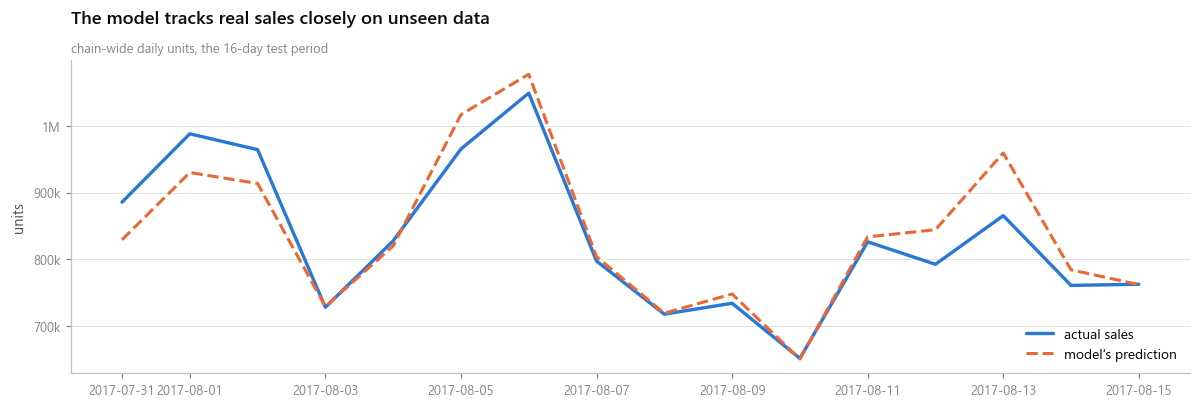

In [10]:
va_info = df.loc[va_m, ["date", "family"]].copy()
va_info["actual"] = y_va
va_info["pred"] = p_va
va_family = va_info.family.to_numpy()
actual_by_date = va_info.groupby("date").actual.sum()
pred_by_date = va_info.groupby("date").pred.sum()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(actual_by_date.index, actual_by_date.values, color=CAT[0], lw=2.2, label="actual sales")
ax.plot(pred_by_date.index, pred_by_date.values, color=CAT[1], lw=2, ls="--",
       label="model's prediction")
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "The model tracks real sales closely on unseen data",
      "chain-wide daily units, the 16-day test period", ylabel="units")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

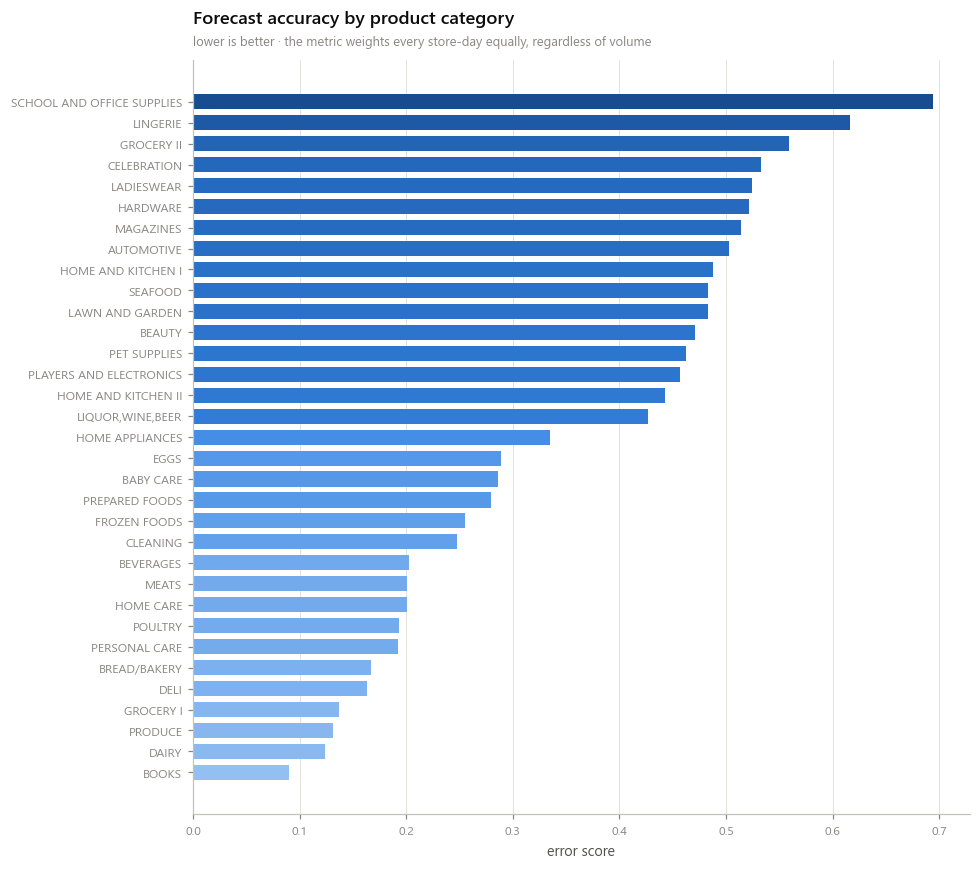

Most accurate categories: BOOKS, DAIRY, PRODUCE
Least accurate categories: GROCERY II, LINGERIE, SCHOOL AND OFFICE SUPPLIES


In [11]:
sq_err = (np.log1p(p_va) - np.log1p(y_va)) ** 2
fam_rmsle = (pd.DataFrame({"family": va_family, "sq_err": sq_err})
            .groupby("family", observed=True).sq_err.mean().pow(0.5).sort_values())

fig, ax = plt.subplots(figsize=(9, 8))
norm = (fam_rmsle - fam_rmsle.min()) / (fam_rmsle.max() - fam_rmsle.min())
ax.barh(fam_rmsle.index.astype(str), fam_rmsle.values,
       color=SEQ(0.2 + 0.65 * norm.values), height=0.72)
ax.tick_params(labelsize=8)
finish(ax, "Forecast accuracy by product category",
      "lower is better · the metric weights every store-day equally, regardless of volume",
      xlabel="error score", ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

print("Most accurate categories:", ", ".join(fam_rmsle.head(3).index.astype(str)))
print("Least accurate categories:", ", ".join(fam_rmsle.tail(3).index.astype(str)))

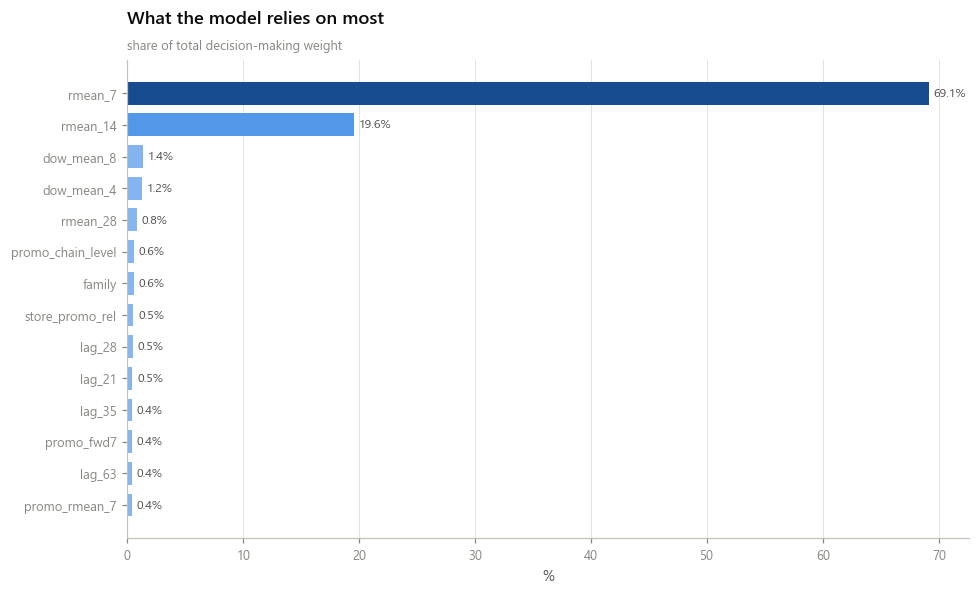

Recent sales history alone accounts for 95% of the model's decisions. Promotions, holidays, and store/category identity make up the rest.


In [12]:
imp = (pd.DataFrame({"feature": model.feature_name(),
                     "gain": model.feature_importance("gain")})
       .assign(share=lambda x: x.gain / x.gain.sum())
       .sort_values("gain", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
top = imp.head(14).iloc[::-1]
norm = (top.share - top.share.min()) / (top.share.max() - top.share.min())
ax.barh(top.feature, top.share * 100, color=SEQ(0.25 + 0.6 * norm.values), height=0.72)
for y, v in enumerate(top.share * 100):
    ax.text(v + 0.4, y, f"{v:.1f}%", va="center", fontsize=8, color=SECOND)
finish(ax, "What the model relies on most", "share of total decision-making weight",
      xlabel="%", ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

recent = imp.feature.str.startswith(("lag_", "rmean_", "dow_mean"))
print(f"Recent sales history alone accounts for {imp.loc[recent, 'share'].sum():.0%} of the "
      f"model's decisions. Promotions, holidays, and store/category identity make up the rest.")

---
## The 16-Day Forecast

The model is now retrained on **all** available history — including the two weeks just used
for testing — before producing the final forecast, so no useful data is left on the table.

In [13]:
full_tr = (df.date <= TRAIN_END) & df.target.notna() & ~eq_row
dfull = lgb.Dataset(df.loc[full_tr, FEATURES], df.loc[full_tr, "target"],
                    categorical_feature=CATS, free_raw_data=False)

te_logs = []
for i, s in enumerate(SEEDS):
    t = time.time()
    m = lgb.train(seed_params(s, i), dfull, num_boost_round=BEST_ROUNDS)
    te_logs.append(m.predict(df.loc[te_m, FEATURES]))
    print(f"  model {i+1}/{len(SEEDS)} trained  ({time.time()-t:.0f}s)")
    del m
    gc.collect()

pred = np.clip(np.expm1(np.mean(te_logs, axis=0)), 0, None)

out = df.loc[te_m, ["date", "store_nbr", "family"]].copy()
out["sales"] = pred
out["family"] = out.family.astype(str)

key = test.assign(family=test.family.astype(str))[["id", "date", "store_nbr", "family"]]
submission = key.merge(out, on=["date", "store_nbr", "family"], how="left")

assert len(submission) == len(test)
assert submission.sales.notna().all()
assert (submission.sales >= 0).all()
assert submission.id.equals(test.id)

submission[["id", "sales"]].to_csv(OUT / "submission.csv", index=False)
print(f"\nforecast written -> {(OUT / 'submission.csv').resolve()}")
print(f"total predicted units, 16 days: {submission.sales.sum():,.0f}")

  model 1/5 trained  (334s)


  model 2/5 trained  (550s)


  model 3/5 trained  (618s)


  model 4/5 trained  (512s)


  model 5/5 trained  (517s)



forecast written -> G:\Meu Drive\_Portifolio\Store Sales - Time Series Forecasting\submissions\stakeholder\submission.csv
total predicted units, 16 days: 12,904,623


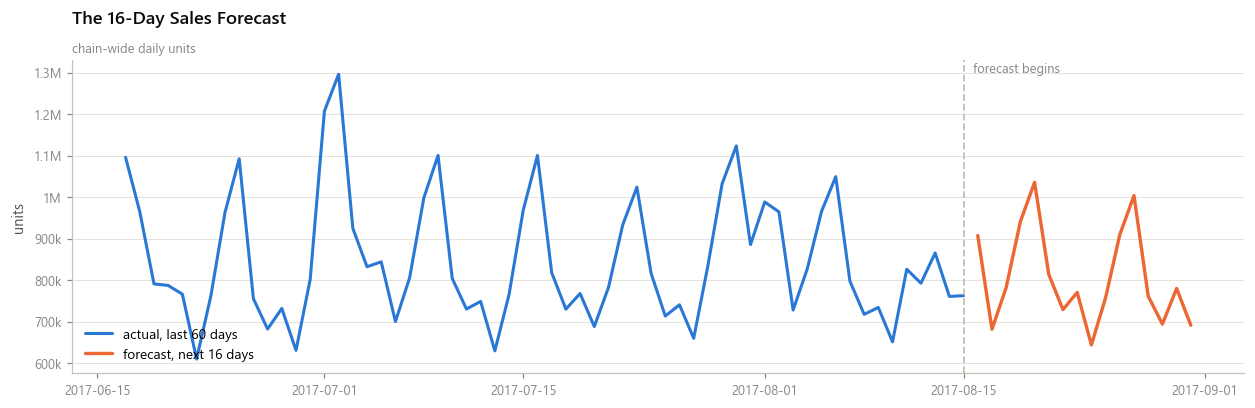

recent actual pace : 832,449 units/day
forecast pace      : 806,539 units/day  (-3.1% vs. the last 16 days)


In [14]:
hist = train[train.date > TRAIN_END - pd.Timedelta(days=60)].groupby("date").sales.sum()
fut = submission.groupby("date").sales.sum()

fig, ax = plt.subplots(figsize=(11.5, 3.8))
ax.plot(hist.index, hist.values, color=CAT[0], lw=2, label="actual, last 60 days")
ax.plot(fut.index, fut.values, color=CAT[1], lw=2.2, label="forecast, next 16 days")
ax.axvline(TRAIN_END, color=AXIS_LINE, lw=1.2, ls="--")
ax.annotate("forecast begins", xy=(TRAIN_END, 0.96), xycoords=("data", "axes fraction"),
           xytext=(6, 0), textcoords="offset points", color=MUTED, fontsize=8.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "The 16-Day Sales Forecast", "chain-wide daily units", ylabel="units")
ax.legend(loc="lower left")
fig.tight_layout(); plt.show()

print(f"recent actual pace : {hist.tail(16).mean():,.0f} units/day")
print(f"forecast pace      : {fut.mean():,.0f} units/day  "
      f"({fut.mean()/hist.tail(16).mean()-1:+.1%} vs. the last 16 days)")

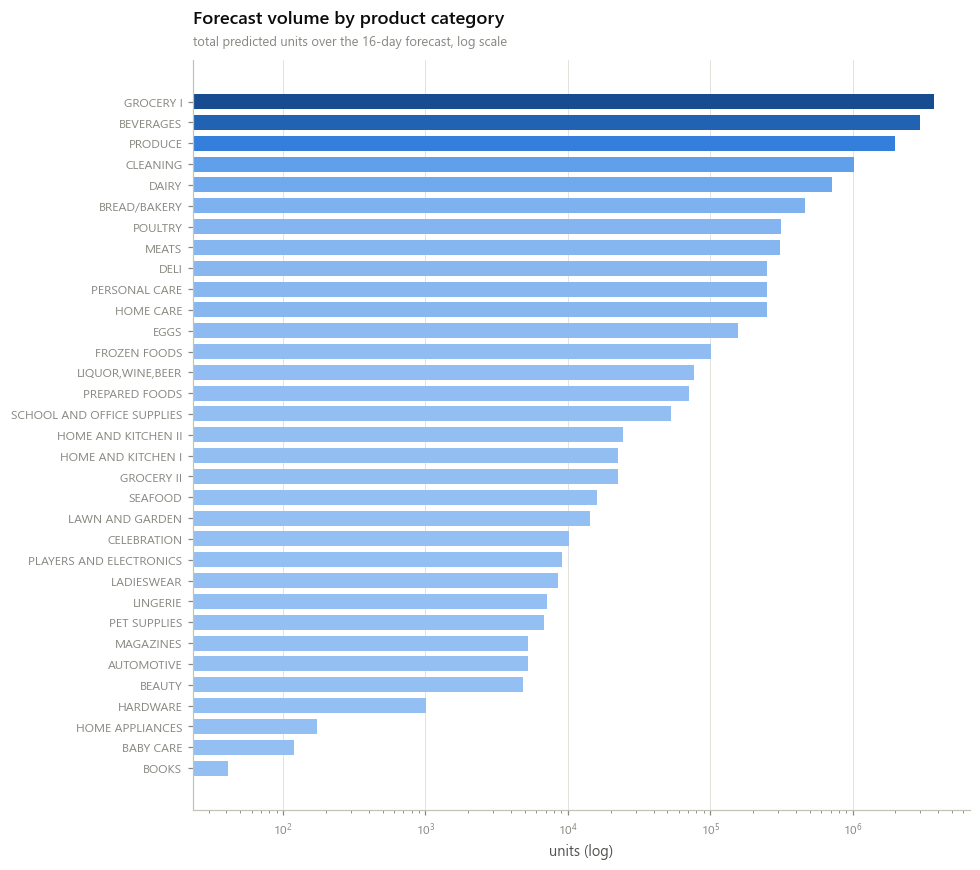

In [15]:
fam_forecast = submission.groupby("family", observed=True).sales.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top = fam_forecast.iloc[::-1]
norm = (top - top.min()) / (top.max() - top.min())
ax.barh(top.index.astype(str), top.values, color=SEQ(0.2 + 0.65 * norm.values), height=0.72)
ax.set_xscale("log")
ax.tick_params(labelsize=8)
finish(ax, "Forecast volume by product category",
      "total predicted units over the 16-day forecast, log scale", xlabel="units (log)",
      ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

---
## Where to Pay Extra Attention

Two things are worth flagging for anyone acting on this forecast.

**A category with limited history for this time of year.** `SCHOOL AND OFFICE SUPPLIES`
consistently scores among the least accurate categories in testing. Ecuador's Sierra school
year starts in September, so this category goes through a sharp back-to-school demand ramp
that only two prior years of August data are available to learn from. It's the single
category most worth a manual sanity check before ordering against the forecast.

**A one-off local holiday inside the forecast window.** Exactly one holiday falls in these
16 days: **Fundacion de Ambato**, a city-specific holiday on 2017-08-24 that only affects the
two stores located in Ambato. Historically this holiday's effect on sales has been
inconsistent — three of the last four years showed little change, one showed a sharp drop —
so there isn't enough history to say confidently which way it will go this time. The chart
below shows what the model currently predicts for those two stores.

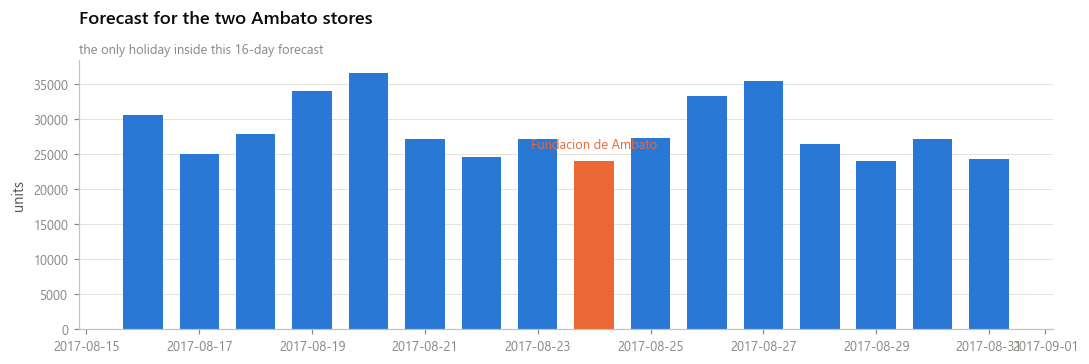

forecast for the holiday itself      : 24,081 units
forecast for other Thursdays in-window: 24,666 units


In [16]:
amb_stores = sorted(stores.loc[stores.city == "Ambato", "store_nbr"])
AMB_DAY = pd.Timestamp("2017-08-24")
amb = submission[submission.store_nbr.isin(amb_stores)].copy()
per_day = amb.groupby("date").sales.sum()

fig, ax = plt.subplots(figsize=(10, 3.4))
cols = [CAT[1] if d == AMB_DAY else CAT[0] for d in per_day.index]
ax.bar(per_day.index, per_day.values, color=cols, width=0.7)
ax.annotate("Fundacion de Ambato", xy=(AMB_DAY, per_day.loc[AMB_DAY]), xytext=(0, 8),
           textcoords="offset points", ha="center", color=CAT[1], fontsize=8.5)
finish(ax, "Forecast for the two Ambato stores",
      "the only holiday inside this 16-day forecast", ylabel="units")
fig.tight_layout(); plt.show()

same_dow = per_day[(per_day.index.dayofweek == AMB_DAY.dayofweek) & (per_day.index != AMB_DAY)]
print(f"forecast for the holiday itself      : {per_day.loc[AMB_DAY]:,.0f} units")
print(f"forecast for other Thursdays in-window: {same_dow.mean():,.0f} units")

---
## How to Use This Forecast

- **Trust the chain-wide and category-level totals most.** They are backed by four and a
  half years of history and consistently score well in testing.
- **Add a buffer for `SCHOOL AND OFFICE SUPPLIES`** and other low-volume, intermittently
  selling categories — the forecast is directionally useful there but carries more
  uncertainty than the categories above.
- **The Ambato stores' forecast for 2017-08-24** should be treated as an estimate with wide
  error bars, given the thin and inconsistent history behind it.
- **Refresh this forecast** as new sales data becomes available — a two-week-ahead forecast
  naturally gets more reliable the closer the forecast origin is to the day being predicted.

### Methodology summary

A gradient-boosted tree model (LightGBM) trained on daily sales from 2015 onward, using
recent sales trends, promotional activity (including known upcoming promotions), the
corrected holiday calendar, paydays, and store/category identity as inputs. Five models with
varied settings are averaged to reduce noise. Accuracy is validated on a 16-day period held
out from training, using the same evaluation approach the forecast itself will ultimately be
judged on.